# Detection ivresse
* Objectif: Détecte les cas d'alcolemi au volant
* Auteurs:
  * Fezeu Ghomsi Eugene Clotaire
* Depot: [github.com/fez2010/detection_de_ivresse_au_volant](https://github.com/fez2010/detection_de_ivresse_au_volant)

In [1]:
!cat /etc/os-release

PRETTY_NAME="Ubuntu 22.04.3 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.3 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy


In [2]:
!pip install seaborn[stats]
!pip install scipy
!pip install numpy
!pip install copulas
!pip install matplotlib
!pip install pandas
!pip install sklearn
!pip install imblearn
!pip install joblib
!pip install mlflow
!pip install shap
!pip install requests
!echo "ttf-mscorefonts-installer msttcorefonts-eula select true" | sudo debconf-set-selections
!sudo apt-get install msttcorefonts ttf-mscorefonts-installer -y --reinstall
!sudo fc-cache -f
!fc-match "Arial"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 2.1 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.4/27.4 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
!pip install opencv-python
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.9/422.9 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.6/969.6 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 286.6/286.6 kB 11.7 MB/s eta 0:00:00


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.stats as stats
import numpy as np
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, ShuffleSplit,cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score, auc
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from imblearn.over_sampling import SVMSMOTE
from joblib import dump, load
from pathlib import Path
import os
import platform
import requests
import mlflow
import math
from sklearn import svm
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.impute import KNNImputer

In [5]:
# Verification de la version de Mlflow
#response = requests.get("http://127.0.0.1:8080/version")

#assert response.text == mlflow.__version__


In [6]:
print(platform.machine(), platform.system(),platform.node(), platform.python_version(), platform.python_compiler(), platform.architecture())

x86_64 Linux 7f954bc7dff2 3.11.11 GCC 11.4.0 ('64bit', 'ELF')


In [7]:
#mpl.set_loglevel("debug")
if platform.system() == 'Linux':
  font_paths = mpl.font_manager.findSystemFonts()
  for font_file in font_paths:
    mpl.font_manager.fontManager.addfont(font_file)

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.figsize'] = (4.6, 4.5)


In [8]:
sns.set_theme(style="white", rc={"grid.linewidth": 0.1, 'figure.figsize':(4.6,4.5)})
sns.set_style("ticks")
sns.set(font='Arial')
sns.set_context("paper", font_scale=0.9)
#plt.figure(figsize=(3.1, 3))
#sns.despine(left=False, bottom=False)

In [9]:

def in_ggole_colab():
  return os.getenv("COLAB_RELEASE_TAG") != None
def set_title(fig, title):
  if(in_ggole_colab()):
    fig.set_title(title)
def title(fig, title):
  if(in_ggole_colab()):
    fig.title(title)
def save_figure(fig,name):
  prefix = './outputs/images/'
  svg_prefix = f'{prefix}svg/'
  png_prefix = f'{prefix}png/'
  eps_prefix = f'{prefix}eps/'
  pdf_prefix = f'{prefix}pdf/'
  prefixs = [svg_prefix, png_prefix, eps_prefix, pdf_prefix]
  prefixs_names = ['svg', 'png', 'eps', 'pdf']
  for p in prefixs:
    Path(p).mkdir(parents=True, exist_ok=True)
  for i in range(len(prefixs)):
    fig.savefig(f'{prefixs[i]}{name}.{prefixs_names[i]}', format=prefixs_names[i], bbox_inches='tight', dpi=96)


In [10]:
#pl.style.use('bmh')

## Effects des drogues par cathegories

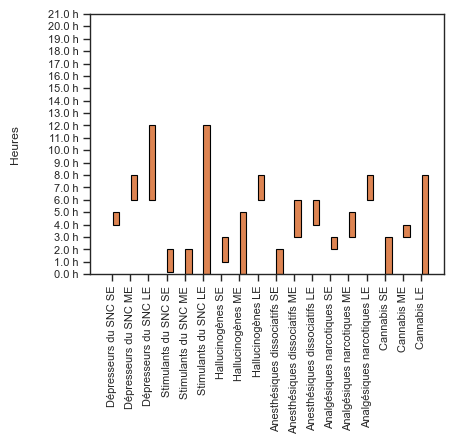

In [11]:
with sns.axes_style("ticks"):



  def hat_graph(ax, xlabels, values, group_labels):
      """
      Create a hat graph.

      Parameters
      ----------
      ax : matplotlib.axes.Axes
          The Axes to plot into.
      xlabels : list of str
          The category names to be displayed on the x-axis.
      values : (M, N) array-like
          The data values.
          Rows are the groups (len(group_labels) == M).
          Columns are the categories (len(xlabels) == N).
      group_labels : list of str
          The group labels displayed in the legend.
      """

      def label_bars(heights, rects):
          """Attach a text label on top of each bar."""
          for height, rect in zip(heights, rects):
              ax.annotate(f'',
                          xy=(rect.get_x() + rect.get_width() / 2, height),
                          xytext=(0, 4),  # 4 points vertical offset.
                          textcoords='offset points',
                          ha='center', va='bottom')

      values = np.asarray(values)
      x = np.arange(values.shape[1])
      ax.set_xticks(x, labels=xlabels)
      spacing = 0.3  # spacing between hat groups
      width = (1 - spacing) / values.shape[0]
      heights0 = values[0]
      for i, (heights, group_label) in enumerate(zip(values, group_labels)):
          style = {'fill': False} if i == 0 else {'edgecolor': 'black'}
          rects = ax.bar(x - spacing/2 + i * width, heights - heights0,
                        width, bottom=heights0, label='', **style)
          label_bars(heights, rects)


  # initialise labels and a numpy array make sure you have
  # N labels of N number of values in the array
  drugs = ['Dépresseurs du SNC','Stimulants du SNC', 'Hallucinogènes', 'Anesthésiques dissociatifs', 'Analgésiques narcotiques', 'Cannabis']
  xlabels = []
  for drug in drugs:
    xlabels.append(f'{drug} SE')
    xlabels.append(f'{drug} ME')
    xlabels.append(f'{drug} LE')
  timeStart = np.array([4, 6, 6, 0.15, 0, 0, 1,0, 6, 0, 3, 4, 2, 3, 6, 0, 3, 0])
  timeEnd = np.array([5, 8, 12, 2, 2, 12, 3, 5, 8, 2, 6, 6, 3, 5, 8, 3, 4, 8])


  fig, ax = plt.subplots(figsize=(4.6, 4.5))
  hat_graph(ax, xlabels, [timeStart, timeEnd], ['Heures min', 'Heures Max'])
  ax.yaxis.set_major_formatter('{x} h')
  # Add some text for labels, title and custom x-axis tick labels, etc.
  #ax.set_xlabel('Drogues')
  ax.set_ylabel('Heures',labelpad=20)
  ax.set_ylim(0, 20)


  ax.set_yticks(np.arange(0, 21.1, 1))
  #ax.set_title('Debuts et fins des effets des drogues apres absortion')
  #ax.legend()
  plt.xticks(rotation=90)

  fig.tight_layout()

  save_figure(fig, 'drugs_effects_durations')

In [12]:
import cv2
import easyocr
reader = easyocr.Reader(['th','en'])


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

## Lecture des données depuis le dépot distant

In [13]:
FILES_PATHS = ['https://github.com/fez2010/detection_de_ivresse_au_volant/raw/refs/heads/main/datasets/DonneesTestSymptomatiqueDRE_A2012.xlsx']

datasets = []
for path in FILES_PATHS:
  #get csv file encoding
  df = pd.read_excel(path,converters={'nr_nan':lambda x: pd.NA if x == '' else int(x)})

  df.columns = df.columns.str.capitalize()
  datasets.append(df)

print(datasets[0].shape)
datasets[0].head()

(116, 50)


,Testno,Nistagmus horizontal,Nistagmus vertical,Convergence,Pupilles,Stimulus,Paupieres,Ambiant,Noirceur,Direct,...,Sautillement,Depot pied,Alcool,Dépresseur,Stimulant,Hallucinogène,Anesthésique dissociatif,Narcotique analgésique,Inhalant,Canabis
0,1,0,0,1,0,1,0,4.0,8.0,4.5,...,1.0,1.0,0,0,1,0,0,0,0.0,0
1,2,0,0,1,0,1,0,6.5,6.5,4.5,...,0.0,1.0,1,0,0,0,0,0,0.0,1
2,3,1,0,1,0,1,0,7.5,7.0,4.5,...,0.0,1.0,1,0,0,0,0,0,0.0,1
3,4,1,0,1,0,1,0,5.5,8.0,4.5,...,0.0,1.0,1,0,0,0,0,0,0.0,1
4,5,1,1,1,0,1,1,3.0,6.5,2.0,...,0.0,1.0,0,1,0,0,0,0,0.0,1


In [14]:
datasets[0].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Testno                    116 non-null    int64  
 1   Nistagmus horizontal      116 non-null    int64  
 2   Nistagmus vertical        116 non-null    int64  
 3   Convergence               116 non-null    int64  
 4   Pupilles                  116 non-null    int64  
 5   Stimulus                  116 non-null    int64  
 6   Paupieres                 116 non-null    int64  
 7   Ambiant                   116 non-null    float64
 8   Noirceur                  116 non-null    float64
 9   Direct                    115 non-null    float64
 10  Dilatation bond           115 non-null    float64
 11  Reaction lum              115 non-null    float64
 12  Injection                 116 non-null    int64  
 13  Romberg 1                 113 non-null    float64
 14  Romberg 2 

In [15]:
datasets[0].head(20)

,Testno,Nistagmus horizontal,Nistagmus vertical,Convergence,Pupilles,Stimulus,Paupieres,Ambiant,Noirceur,Direct,...,Sautillement,Depot pied,Alcool,Dépresseur,Stimulant,Hallucinogène,Anesthésique dissociatif,Narcotique analgésique,Inhalant,Canabis
0,1,0,0,1,0,1,0,4.0,8.0,4.5,...,1.0,1.0,0,0,1,0,0,0,0.0,0
1,2,0,0,1,0,1,0,6.5,6.5,4.5,...,0.0,1.0,1,0,0,0,0,0,0.0,1
2,3,1,0,1,0,1,0,7.5,7.0,4.5,...,0.0,1.0,1,0,0,0,0,0,0.0,1
3,4,1,0,1,0,1,0,5.5,8.0,4.5,...,0.0,1.0,1,0,0,0,0,0,0.0,1
4,5,1,1,1,0,1,1,3.0,6.5,2.0,...,0.0,1.0,0,1,0,0,0,0,0.0,1
5,6,1,0,0,0,1,1,3.0,7.5,3.5,...,0.0,1.0,0,1,0,0,0,0,0.0,1
6,7,1,0,0,0,1,0,5.5,8.5,5.0,...,1.0,1.0,0,1,1,0,0,0,0.0,0
7,8,1,0,1,0,1,0,3.0,4.0,1.5,...,0.0,1.0,0,1,1,0,0,0,0.0,0
8,9,1,0,1,0,1,0,5.5,8.0,4.0,...,1.0,1.0,0,1,1,0,0,0,0.0,0
9,10,1,0,0,0,1,0,4.5,9.0,5.0,...,0.0,0.0,1,1,1,0,0,0,0.0,0


In [16]:
datasets[0]['Reaction lum'].unique()

array([ 1.,  0.,  2., nan])

In [17]:

# Création des ensembles de nom
CATEGORY_COLUMNS= []
QUANTITATIVE_COLUMNS = ['Reaction lum','Depot pied','Sautillement','Bras','Balancement','Equi d', 'Equi g', 'Pas 2','Pas 1','Pivot incorrect','Utilisation bras','Pas hors ligne','Talon/orteille','Depart hatif','Larmoyant','Conjonctive rouge','Injecté sang', 'Yeux normaux', 'Ambiant', 'Noirceur','Direct','Dilatation bond','Romberg 1','Romberg 2', 'Romberg 3', 'Température', 'Tension a', 'Tension b', 'Test toucher']
REAL_QUANTITATIVE_COLUMNS = ['Reaction lum','Depot pied','Sautillement','Bras','Balancement','Equi d', 'Equi g', 'Pas 2','Pas 1','Pivot incorrect','Utilisation bras','Pas hors ligne','Talon/orteille', 'Depart hatif','Larmoyant','Conjonctive rouge','Injecté sang', 'Yeux normaux', 'Ambiant', 'Noirceur','Direct','Dilatation bond','Romberg 1','Romberg 2', 'Romberg 3', 'Température', 'Tension a', 'Tension b', 'Test toucher']
INTEGER_QUANTITATIVE_COLUMNS = ['Tonus musculaire','Paupieres', 'Pupilles', 'Perte equilibre', 'Pouls', 'Injection', 'Nistagmus horizontal', 'Nistagmus vertical', 'Convergence']
TESTS =  ['Stimulus','Test arrêté 1','Arret marche']
LABELS = ['Inhalant','Canabis', 'Narcotique analgésique', 'Anesthésique dissociatif', 'Hallucinogène', 'Stimulant', 'Dépresseur', 'Alcool']
IDS = ['Testno']
# Liste des variables explicatives
EXPLICATIVES_COLUMNS = CATEGORY_COLUMNS + QUANTITATIVE_COLUMNS + INTEGER_QUANTITATIVE_COLUMNS
# Classe Cible
TARGET = 'Event'
# Codes Couleur
COLOR_PALETTE = ['#8B383F','#373D61','#203AE0']

In [18]:
len(EXPLICATIVES_COLUMNS) + len(LABELS) + len(IDS)

47

In [19]:
HIDDEN_LABELS = []
for column in LABELS:
  HIDDEN_LABELS.append(f'Pas {column}')

In [20]:
datasets[0].iloc[1][LABELS].astype('int64').to_dict()

{'Inhalant': 0,
 'Canabis': 1,
 'Narcotique analgésique': 0,
 'Anesthésique dissociatif': 0,
 'Hallucinogène': 0,
 'Stimulant': 0,
 'Dépresseur': 0,
 'Alcool': 1}

In [87]:
pencode(datasets[0].iloc[1][LABELS].astype('int64').to_dict())

66

In [97]:
bin(66)

'0b1000010'

# Recherche des valeurs manquantes

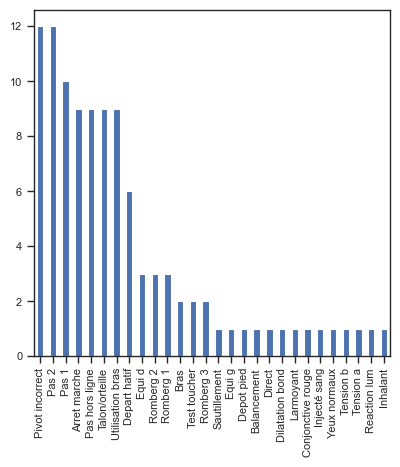

In [21]:
with sns.axes_style("ticks"):
  fig = plt.figure()

  has_empties_values = datasets[0].isnull().sum()

  has_empties_values = has_empties_values.iloc[(has_empties_values > 0).to_list()].sort_values(ascending=False)

  has_empties_values.plot(kind='bar')

  save_figure(plt, 'missings_values')

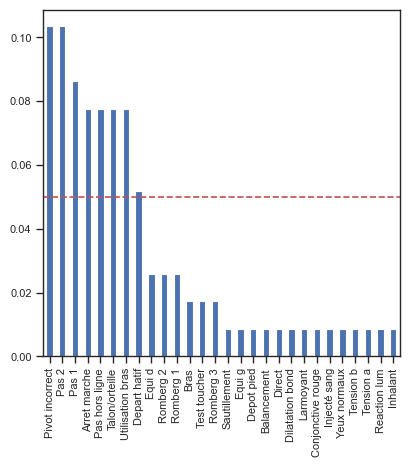

In [22]:
with sns.axes_style("ticks"):
  has_empties_values_ratio = has_empties_values/datasets[0].shape[0]
  fig = has_empties_values_ratio.plot(kind='bar')
  threshold=0.05
  fig.axhline(y=threshold, color='r', linestyle='--')

  save_figure(plt, 'missings_values_ratio')

In [23]:
#missing value by column rations
has_empties_values_ratio.sum()/datasets[0].shape[1]

0.018103448275862067

# Liste de valeurs des variables catégoriels


In [24]:
print(CATEGORY_COLUMNS)
for column in CATEGORY_COLUMNS:
  print(f'Les valeurs de la colonne {column} sont : ',', '.join(datasets[0][column].unique()))


[]


In [25]:
def get_description(dataset):
  description = dataset.describe(include='all')
  description = dataset.describe(include='all')
  description.loc['var'] = dataset.var().tolist()
  description.loc['skew'] = dataset.skew().tolist()
  description.loc['kurt'] = dataset.kurtosis().tolist()
  return description
print(get_description(datasets[0]))
#stats.normaltest(datasets[1][TARGET])
Path("./outputs/csv/").mkdir(parents=True, exist_ok=True)
get_description(datasets[0]).to_csv('./outputs/csv/stats.csv')


            Testno  Nistagmus horizontal  Nistagmus vertical  Convergence  \
count   116.000000            116.000000          116.000000   116.000000   
mean     58.500000              0.474138            0.129310     0.465517   
std      33.630343              0.501497            0.336999     0.500974   
min       1.000000              0.000000            0.000000     0.000000   
25%      29.750000              0.000000            0.000000     0.000000   
50%      58.500000              0.000000            0.000000     0.000000   
75%      87.250000              1.000000            0.000000     1.000000   
max     116.000000              1.000000            1.000000     1.000000   
var    1131.000000              0.251499            0.113568     0.250975   
skew      0.000000              0.104949            2.238542     0.140078   
kurt     -1.200000             -2.024191            3.063598    -2.015432   

         Pupilles  Stimulus   Paupieres     Ambiant    Noirceur      Direct

In [26]:
datasets[0][LABELS].value_counts()


Inhalant  Canabis  Narcotique analgésique  Anesthésique dissociatif  Hallucinogène  Stimulant  Dépresseur  Alcool
0.0       1        0                       0                         0              0          0           0         25
          0        0                       0                         0              1          0           0         23
                                                                                    0          1           0         18
                                                                                                           1          8
          1        0                       0                         0              0          0           1          7
          0        0                       0                         1              0          0           0          6
                                                                     0              1          1           0          5
                                                                                               0           1          4
                                           1                         0              0          0           0          3
          1        0                       0                         0              0          1           0          3
          0        1                       0                         0              0          0           0          3
                   0                       0                         0              1          1           1          2
                                                                     1              0          0           1          2
                   1                       0                         0              1          0           0          2
          1        0                       0                         0              0          1           1          1
          0        0                       0                         0              0          0           1          1
                                           1                         0              0          1           1          1
1.0       0        0                       0                         0              0          1           0          1
Name: count, dtype: int64

In [27]:
#Binarisation et gestion des etats caches sur les labels


In [28]:
def labels_binarisation(dataset):
  lab = dict.fromkeys([*LABELS,*HIDDEN_LABELS], [])
  for column in [*LABELS,*HIDDEN_LABELS]:
    lab[column] = []
  isNulls = dataset.isnull()

  for i in dataset.index:
    for column in LABELS:
      if isNulls[column][i]:
        lab[f'Pas {column}'].append(1)
      else:
        lab[f'Pas {column}'].append(0)
      if dataset[column][i] == 1:
        lab[column].append(1)

      else:
        lab[column].append(0)


  for column in [*LABELS,*HIDDEN_LABELS]:

    dataset[column] = np.array(lab[column])



  return dataset

In [29]:
d1 = labels_binarisation(datasets[0])
d1.head()

,Testno,Nistagmus horizontal,Nistagmus vertical,Convergence,Pupilles,Stimulus,Paupieres,Ambiant,Noirceur,Direct,...,Inhalant,Canabis,Pas Inhalant,Pas Canabis,Pas Narcotique analgésique,Pas Anesthésique dissociatif,Pas Hallucinogène,Pas Stimulant,Pas Dépresseur,Pas Alcool
0,1,0,0,1,0,1,0,4.0,8.0,4.5,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,1,0,1,0,6.5,6.5,4.5,...,0,1,0,0,0,0,0,0,0,0
2,3,1,0,1,0,1,0,7.5,7.0,4.5,...,0,1,0,0,0,0,0,0,0,0
3,4,1,0,1,0,1,0,5.5,8.0,4.5,...,0,1,0,0,0,0,0,0,0,0
4,5,1,1,1,0,1,1,3.0,6.5,2.0,...,0,1,0,0,0,0,0,0,0,0


In [30]:
print(d1[LABELS+HIDDEN_LABELS].value_counts())


Inhalant  Canabis  Narcotique analgésique  Anesthésique dissociatif  Hallucinogène  Stimulant  Dépresseur  Alcool  Pas Inhalant  Pas Canabis  Pas Narcotique analgésique  Pas Anesthésique dissociatif  Pas Hallucinogène  Pas Stimulant  Pas Dépresseur  Pas Alcool
0         1        0                       0                         0              0          0           0       0             0            0                           0                             0                  0              0               0             25
          0        0                       0                         0              1          0           0       0             0            0                           0                             0                  0              0               0             23
                                                                                    0          1           0       0             0            0                           0                             0    

## Encodage des labels
Ranger par ordre de covariance total max et prendre le plus grand

In [31]:
pmsb = abs(d1[LABELS].corr().sum()).sort_values(ascending=False)
print(pmsb)


Inhalant                    0.890501
Alcool                      0.888815
Anesthésique dissociatif    0.607952
Narcotique analgésique      0.510272
Dépresseur                  0.346255
Hallucinogène               0.313996
Canabis                     0.297203
Stimulant                   0.096073
dtype: float64


In [32]:
HIDDEN_LABELS

['Pas Inhalant',
 'Pas Canabis',
 'Pas Narcotique analgésique',
 'Pas Anesthésique dissociatif',
 'Pas Hallucinogène',
 'Pas Stimulant',
 'Pas Dépresseur',
 'Pas Alcool']

In [33]:
nmsb = abs(d1[HIDDEN_LABELS].corr().sum()).sort_values(ascending=False)
print(nmsb)

Pas Inhalant                    1.0
Pas Canabis                     0.0
Pas Narcotique analgésique      0.0
Pas Anesthésique dissociatif    0.0
Pas Hallucinogène               0.0
Pas Stimulant                   0.0
Pas Dépresseur                  0.0
Pas Alcool                      0.0
dtype: float64


In [34]:
def pencode(value):
  r = 0
  for i in range(len(LABELS)):
    if value[pmsb.keys()[i]] == 1:
      r = r + 2**(i)


  return r

def pdencode(value):

  return bin(value)[0] + bin(value)[2:]


  return r
def nencode(value):
  r = 0
  for i in range(len(HIDDEN_LABELS)):
    if value[nmsb.keys()[i]] == 1:
      r = r + 2**(i)
  return r


In [96]:

  print(i)

0


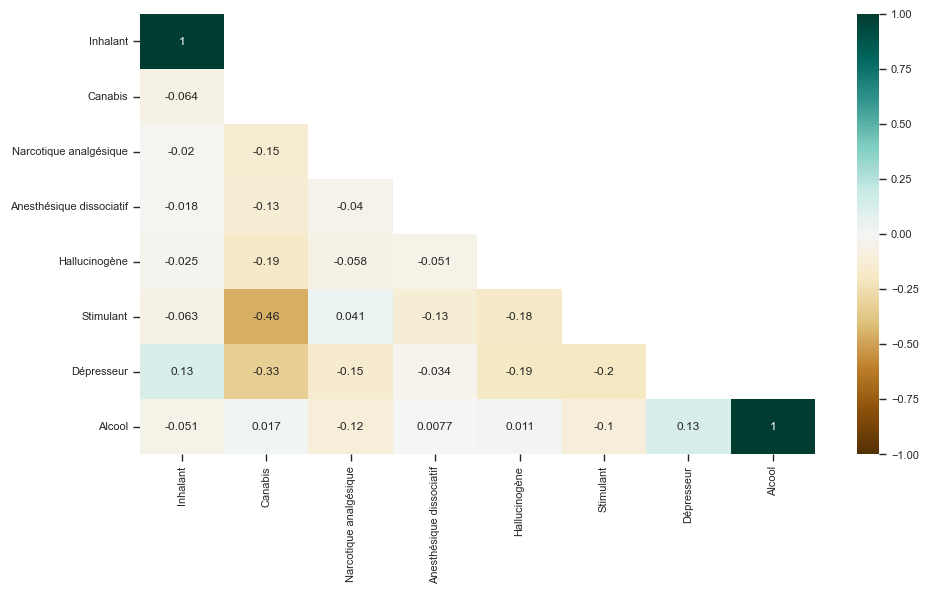

In [35]:
with sns.axes_style("ticks"):
  plt.figure(figsize=(10, 6))
  mask = np.triu(np.ones_like(d1[LABELS].corr()))
  mask[0][0] = False
  mask[mask.shape[0]-1][mask.shape[1]-1] = False
  heatmap = sns.heatmap(d1[LABELS].corr(), mask=mask, vmin=-1, vmax=1, annot=True, cmap='BrBG')
  plt.tight_layout()

In [36]:
d1[LABELS].iloc[1]['Inhalant']

0

In [37]:
d1[EXPLICATIVES_COLUMNS].head(1)

,Reaction lum,Depot pied,Sautillement,Bras,Balancement,Equi d,Equi g,Pas 2,Pas 1,Pivot incorrect,...,Test toucher,Tonus musculaire,Paupieres,Pupilles,Perte equilibre,Pouls,Injection,Nistagmus horizontal,Nistagmus vertical,Convergence
0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,10.0,10.0,1.0,...,0.0,0,0,0,1,100,0,0,0,1


In [38]:
# Create target column
d1[TARGET] = [0] * d1.shape[0]
for i in d1.index:
  pencoded = pencode(d1[LABELS].iloc[i])
  nencoded = nencode(d1[HIDDEN_LABELS].iloc[i])

  d1[TARGET][i] = pencoded + nencoded * 10**-2

d1[TARGET]

<ipython-input-38-0629f359505a>:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  d1[TARGET][i] = pencoded + nencoded * 10**-2
<ipython-input-38-0629f359505a>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

,Event
0,128.0
1,66.0
2,66.0
3,66.0
4,80.0
...,...
111,64.0
112,64.0
113,64.0
114,64.0


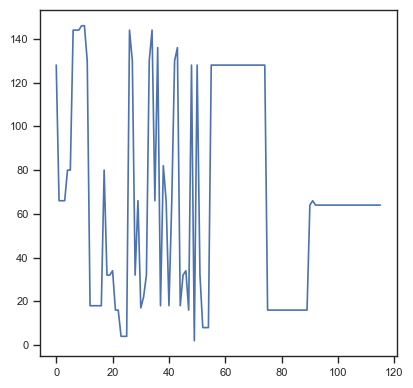

In [39]:
with sns.axes_style("ticks"):
  d1[TARGET].plot(kind="line")

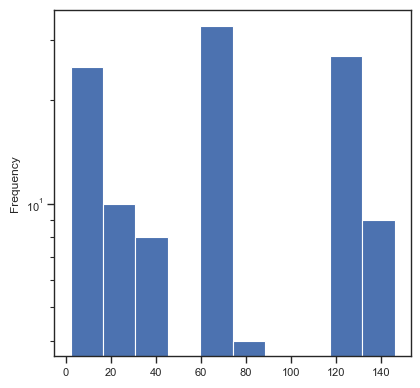

In [40]:
with sns.axes_style("ticks"):
  d1[TARGET].plot(kind="hist", log=True)


In [41]:
d1[TARGET].to_numpy().reshape(-1, 1)

array([[128.  ],
       [ 66.  ],
       [ 66.  ],
       [ 66.  ],
       [ 80.  ],
       [ 80.  ],
       [144.  ],
       [144.  ],
       [144.  ],
       [146.  ],
       [146.  ],
       [130.  ],
       [ 18.  ],
       [ 18.  ],
       [ 18.  ],
       [ 18.  ],
       [ 18.  ],
       [ 80.  ],
       [ 32.  ],
       [ 32.  ],
       [ 34.  ],
       [ 16.  ],
       [ 16.  ],
       [  4.  ],
       [  4.  ],
       [  4.  ],
       [144.  ],
       [130.  ],
       [ 32.  ],
       [ 66.  ],
       [ 17.  ],
       [ 22.  ],
       [ 32.  ],
       [130.  ],
       [144.  ],
       [ 66.  ],
       [136.  ],
       [ 18.  ],
       [ 82.  ],
       [ 66.  ],
       [ 18.  ],
       [ 66.  ],
       [130.  ],
       [136.  ],
       [ 18.  ],
       [ 32.  ],
       [ 34.  ],
       [ 16.  ],
       [128.  ],
       [  2.  ],
       [128.  ],
       [ 32.  ],
       [  8.  ],
       [  8.  ],
       [  8.  ],
       [128.  ],
       [128.  ],
       [128.  ],
       [128.  

In [42]:
d1[TARGET].astype('float')
scaler = StandardScaler()
f_scaler = scaler
d1[f'NORM_{TARGET}'] = scaler.fit_transform(d1[TARGET].to_numpy().reshape(-1, 1))

<Axes: >

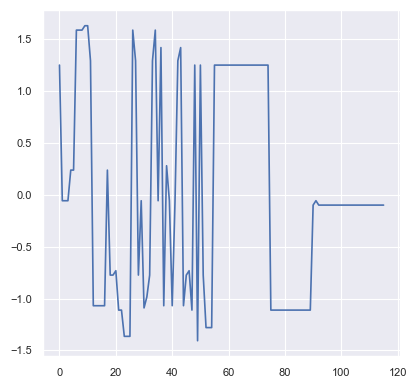

In [43]:
d1[f'NORM_{TARGET}'].plot(kind="line")

<Axes: >

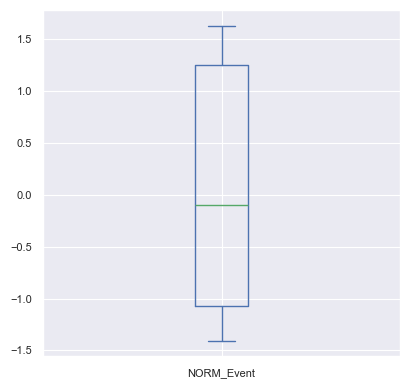

In [44]:
d1[f'NORM_{TARGET}'].plot(kind="box")


In [45]:
get_description(d1[[f'NORM_{TARGET}']])

,NORM_Event
count,1.160000e+02
mean,-6.484277e-17
std,1.004338e+00
min,-1.407382e+00
25%,-1.069684e+00
50%,-9.880048e-02
75%,1.251994e+00
max,1.631905e+00
var,1.008696e+00
skew,2.732007e-01


In [46]:
d2 = d1.copy()


In [47]:
d2 = d2.dropna()

In [48]:
d2.shape

(96, 60)

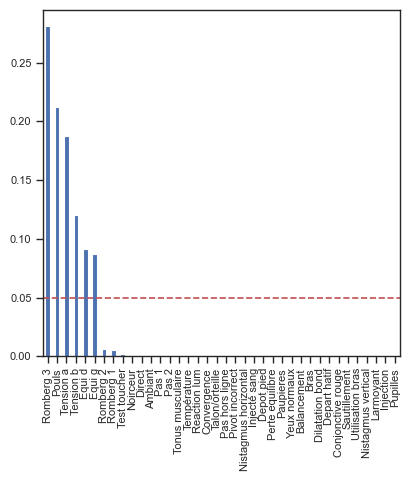

In [49]:
with sns.axes_style("ticks"):
  total_var = d2[EXPLICATIVES_COLUMNS].var().sum()
  fig = (d2[EXPLICATIVES_COLUMNS].var()/total_var).sort_values(ascending=False).plot(kind="bar")
  threshold=0.05
  fig.axhline(y=threshold, color='r', linestyle='--')



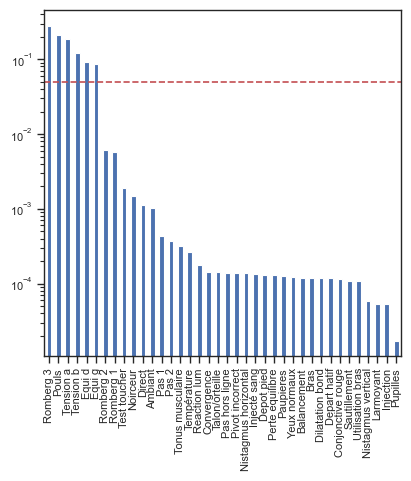

In [50]:
  with sns.axes_style("ticks"):
    total_var = d2[EXPLICATIVES_COLUMNS].var().sum()
    fig=(d2[EXPLICATIVES_COLUMNS].var()/total_var).sort_values(ascending=False).plot(kind="bar", log=True)
    fig.axhline(y=threshold, color='r', linestyle='--')

In [51]:
corr = d2[EXPLICATIVES_COLUMNS].dropna().corr(method="kendall")
columns = corr.columns

In [52]:
corr

,Reaction lum,Depot pied,Sautillement,Bras,Balancement,Equi d,Equi g,Pas 2,Pas 1,Pivot incorrect,...,Test toucher,Tonus musculaire,Paupieres,Pupilles,Perte equilibre,Pouls,Injection,Nistagmus horizontal,Nistagmus vertical,Convergence
Reaction lum,1.000000,-0.055216,0.037488,0.274251,0.077960,-0.072397,0.095960,0.033776,-0.030105,0.077009,...,0.075553,0.131593,0.183852,0.040004,-0.018523,-0.177499,0.132570,-0.015402,-0.063571,0.087322
Depot pied,-0.055216,1.000000,0.202908,0.132924,0.180538,-0.473707,-0.508578,-0.042931,0.133735,0.062189,...,-0.120781,0.104232,0.001424,0.011661,0.117844,0.121588,0.045756,0.069506,0.068654,0.064927
Sautillement,0.037488,0.202908,1.000000,0.224112,0.224112,-0.157249,-0.181625,0.018726,0.163764,0.068205,...,0.036265,0.022036,-0.029672,0.029841,0.042392,-0.033963,0.186157,-0.116350,-0.064428,0.023736
Bras,0.274251,0.132924,0.224112,1.000000,0.294118,-0.152862,-0.202690,0.073357,0.061225,0.201435,...,-0.017323,0.125002,0.174912,-0.016464,0.099830,0.008630,-0.006252,0.030990,0.086940,0.000000
Balancement,0.077960,0.180538,0.224112,0.294118,1.000000,-0.204504,-0.194734,0.041328,-0.116061,-0.077475,...,-0.083300,0.034575,0.126660,0.115251,0.051912,-0.108387,0.143792,0.077475,0.230840,-0.045835
Equi d,-0.072397,-0.473707,-0.157249,-0.152862,-0.204504,1.000000,0.565021,-0.087369,-0.126334,-0.045073,...,0.025128,-0.193229,-0.160784,-0.042271,-0.261106,-0.010861,-0.106552,-0.101572,-0.123315,-0.055709
Equi g,0.095960,-0.508578,-0.181625,-0.202690,-0.194734,0.565021,1.000000,-0.047971,-0.194591,-0.048472,...,0.060442,-0.130781,-0.119163,-0.028914,-0.255090,0.018413,0.104476,-0.175710,-0.126358,-0.007546
Pas 2,0.033776,-0.042931,0.018726,0.073357,0.041328,-0.087369,-0.047971,1.000000,0.301628,0.010478,...,0.081934,-0.060168,0.101842,0.168692,-0.113413,0.066886,0.029209,-0.123357,-0.098047,0.046492
Pas 1,-0.030105,0.133735,0.163764,0.061225,-0.116061,-0.126334,-0.194591,0.301628,1.000000,0.250818,...,-0.269007,-0.145582,0.053496,-0.045896,0.120927,-0.004549,0.062581,-0.107494,-0.086609,-0.026135
Pivot incorrect,0.077009,0.062189,0.068205,0.201435,-0.077475,-0.045073,-0.048472,0.010478,0.250818,1.000000,...,-0.199473,0.022068,0.166821,-0.091077,0.125173,-0.073832,-0.057639,0.200000,-0.027639,0.000000


In [53]:
#Link testng for regression
EXPLICATIVES_COLUMNS

['Reaction lum',
 'Depot pied',
 'Sautillement',
 'Bras',
 'Balancement',
 'Equi d',
 'Equi g',
 'Pas 2',
 'Pas 1',
 'Pivot incorrect',
 'Utilisation bras',
 'Pas hors ligne',
 'Talon/orteille',
 'Depart hatif',
 'Larmoyant',
 'Conjonctive rouge',
 'Injecté sang',
 'Yeux normaux',
 'Ambiant',
 'Noirceur',
 'Direct',
 'Dilatation bond',
 'Romberg 1',
 'Romberg 2',
 'Romberg 3',
 'Température',
 'Tension a',
 'Tension b',
 'Test toucher',
 'Tonus musculaire',
 'Paupieres',
 'Pupilles',
 'Perte equilibre',
 'Pouls',
 'Injection',
 'Nistagmus horizontal',
 'Nistagmus vertical',
 'Convergence']

In [54]:
i = 0
mask_links = corr.copy()
for column in corr.columns:
  mask_links[column] = corr[column].apply(lambda x: 1 if abs(x) >= 0.05 else 0)
  mask_links[column][i] = 0
  i = i + 1

<ipython-input-54-31aa837aadb2>:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  mask_links[column][i] = 0
<ipython-input-54-31aa837aadb2>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the

In [55]:
mask_links

#1,8,9,10,11,15,16,17,18,19,20,37,38

,Reaction lum,Depot pied,Sautillement,Bras,Balancement,Equi d,Equi g,Pas 2,Pas 1,Pivot incorrect,...,Test toucher,Tonus musculaire,Paupieres,Pupilles,Perte equilibre,Pouls,Injection,Nistagmus horizontal,Nistagmus vertical,Convergence
Reaction lum,0,1,0,1,1,1,1,0,0,1,...,1,1,1,0,0,1,1,0,1,1
Depot pied,1,0,1,1,1,1,1,0,1,1,...,1,1,0,0,1,1,0,1,1,1
Sautillement,0,1,0,1,1,1,1,0,1,1,...,0,0,0,0,0,0,1,1,1,0
Bras,1,1,1,0,1,1,1,1,1,1,...,0,1,1,0,1,0,0,0,1,0
Balancement,1,1,1,1,0,1,1,0,1,1,...,1,0,1,1,1,1,1,1,1,0
Equi d,1,1,1,1,1,0,1,1,1,0,...,0,1,1,0,1,0,1,1,1,1
Equi g,1,1,1,1,1,1,0,0,1,0,...,1,1,1,0,1,0,1,1,1,0
Pas 2,0,0,0,1,0,1,0,0,1,0,...,1,1,1,1,1,1,0,1,1,0
Pas 1,0,1,1,1,1,1,1,1,0,1,...,1,1,1,0,1,0,1,1,1,0
Pivot incorrect,1,1,1,1,1,0,0,0,1,0,...,1,0,1,1,1,1,1,1,0,0


In [56]:
regressor = dict.fromkeys(EXPLICATIVES_COLUMNS, [])
for column in EXPLICATIVES_COLUMNS:
  possibleEXP = mask_links[column]
  r = []
  for i in possibleEXP.index:

    if possibleEXP[i] == 1:
      r.append(i)
  poly = PolynomialFeatures(interaction_only=True)
  print(column,r )
  X =  d2[r]
  scoring = ['precision_macro']
  if(len(r)==0 or len(d2[column].unique()) < 2):
    regressor[column] = None
    continue
  if len(d2[column].unique()) <= 2:
    le = LabelEncoder()
    clf= make_pipeline(StandardScaler(),LogisticRegression( penalty='l2', solver='newton-cg', random_state=0, C=1, max_iter=1000))
    cv = ShuffleSplit(n_splits=30, test_size=0.3, random_state=0)
    scores = cross_val_score(clf, X,le.fit_transform (d2[column]), cv=cv,  )
    regressor[column] = [r,le,clf]
  elif column in INTEGER_QUANTITATIVE_COLUMNS:
    le = LabelEncoder()
    clf= make_pipeline(StandardScaler(),LinearRegression( ))
    cv = ShuffleSplit(n_splits=30, test_size=0.3, random_state=0)
    scores = cross_val_score(clf, X,le.fit_transform (d2[column]), cv=cv,  )
    regressor[column] = [r,le,clf]
  else:
    clf= make_pipeline(StandardScaler(), LinearRegression( ) )
    cv = ShuffleSplit(n_splits=30, test_size=0.3, random_state=0)
    scores = cross_val_score(clf, X,d2[column], cv=cv,  )
    regressor[column] = [r,clf]

  print(scores)

Reaction lum ['Depot pied', 'Bras', 'Balancement', 'Equi d', 'Equi g', 'Pivot incorrect', 'Utilisation bras', 'Talon/orteille', 'Depart hatif', 'Larmoyant', 'Conjonctive rouge', 'Injecté sang', 'Direct', 'Dilatation bond', 'Romberg 1', 'Température', 'Tension a', 'Tension b', 'Test toucher', 'Tonus musculaire', 'Paupieres', 'Pouls', 'Injection', 'Nistagmus vertical', 'Convergence']
[-0.08887413 -0.8777095  -0.56822573 -0.76098535 -0.71632824 -0.59656493
 -0.41424243 -0.87381379 -0.3709784   0.06337037 -0.24180974 -0.59461025
 -0.4421395  -0.46203939  0.04692459 -0.38717188 -0.45174808 -0.72854216
 -0.33932187 -0.28183262 -0.91376012  0.07638163 -0.83514463 -0.19969586
 -0.60068871 -1.0162683   0.37648319 -1.1705296  -0.25634292 -0.51843133]
Depot pied ['Reaction lum', 'Sautillement', 'Bras', 'Balancement', 'Equi d', 'Equi g', 'Pas 1', 'Pivot incorrect', 'Utilisation bras', 'Pas hors ligne', 'Talon/orteille', 'Larmoyant', 'Conjonctive rouge', 'Injecté sang', 'Yeux normaux', 'Noirceur', 

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
1 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py", line 660, in fit
    self._final_estimator.fit(Xt, y, **last

[1.         0.93103448 0.96551724 0.96551724 0.96551724 0.96551724
 0.93103448 1.         0.93103448 0.96551724 0.93103448 1.
 0.96551724 1.         1.         1.         0.93103448 0.93103448
 0.96551724        nan 0.96551724 0.96551724 0.96551724 0.93103448
 1.         1.         0.96551724 0.93103448 1.         0.96551724]
Perte equilibre ['Depot pied', 'Bras', 'Balancement', 'Equi d', 'Equi g', 'Pas 2', 'Pas 1', 'Pivot incorrect', 'Utilisation bras', 'Pas hors ligne', 'Talon/orteille', 'Depart hatif', 'Conjonctive rouge', 'Injecté sang', 'Ambiant', 'Direct', 'Romberg 1', 'Romberg 2', 'Romberg 3', 'Température', 'Tension a', 'Test toucher', 'Tonus musculaire', 'Paupieres', 'Pouls', 'Injection', 'Nistagmus horizontal', 'Nistagmus vertical']
[0.62068966 0.62068966 0.65517241 0.55172414 0.5862069  0.51724138
 0.72413793 0.55172414 0.51724138 0.65517241 0.62068966 0.5862069
 0.55172414 0.65517241 0.68965517 0.62068966 0.51724138 0.51724138
 0.48275862 0.65517241 0.5862069  0.5862069  0.

In [57]:
d3 = d1[d1.columns]
np.random.seed(0)
namap = d3.isna()
def fixe_missing(column,i):
  print(column,i)
  if regressor[column] == None:

    return np.random.choice(d2[column].unique())
  elif len(regressor[column]) == 2:
    return regressor[column][1].predict(d3[regressor[column][0]][i].fillna(0))[0]
  else :
    le = regressor[column][1]
    clf = regressor[column][2]
    return le.inverse_transform([regressor[column][0].predict(d3[regressor[column][0]][i].fillna(0))])[0]



In [58]:
d3.shape

(116, 60)

In [59]:
imputer = KNNImputer(n_neighbors=2)
d3[d3.columns] = imputer.fit_transform(d3)

In [60]:
d3.isna().sum()

,0
Testno,0
Nistagmus horizontal,0
Nistagmus vertical,0
Convergence,0
Pupilles,0
Stimulus,0
Paupieres,0
Ambiant,0
Noirceur,0
Direct,0


['Nistagmus horizontal', 'Dilatation bond', 'Reaction lum']


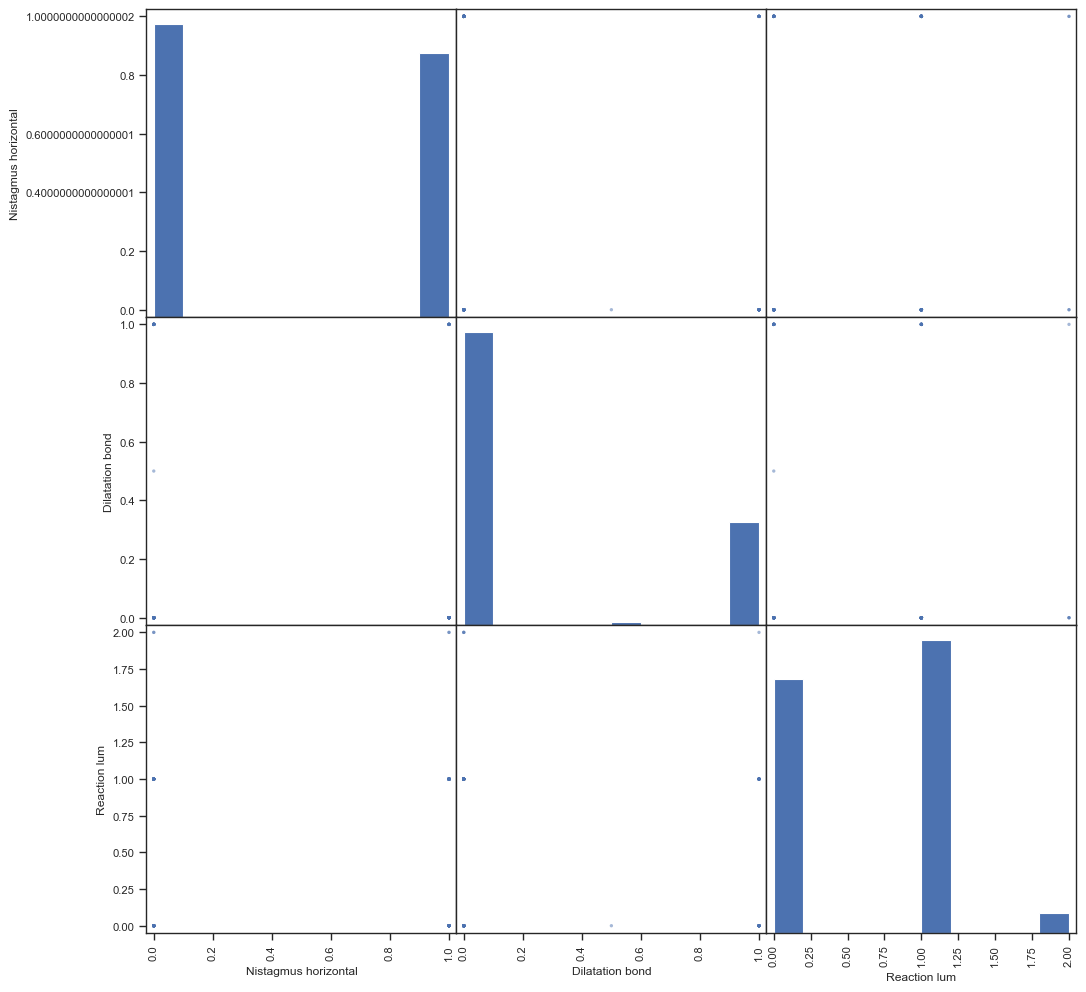

In [61]:
with sns.axes_style("ticks"):
  a = [1,10,11,]
  c = []
  for i in a:
    c.append(d3.columns[i])
  print(c)
  pd.plotting.scatter_matrix(d3[c],figsize=(12,12));

['Noirceur', 'Direct', 'Romberg 3', 'Pouls', 'Température', 'Tension a']


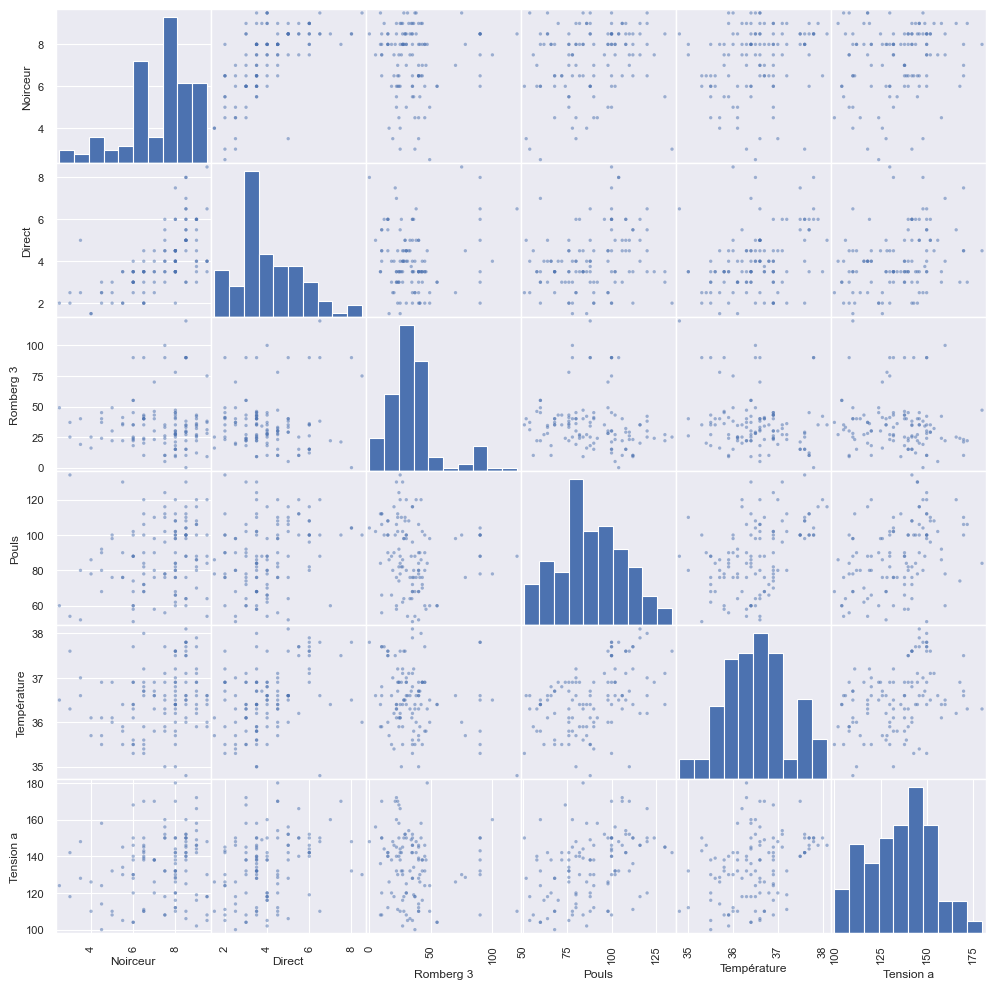

In [62]:
a = [8,9,15,16,17,18]
c = []
for i in a:
  c.append(d1.columns[i])
print(c)
pd.plotting.scatter_matrix(d3[c],figsize=(12,12));

['Tension b', 'Test toucher', 'Equi d', 'Balancement']


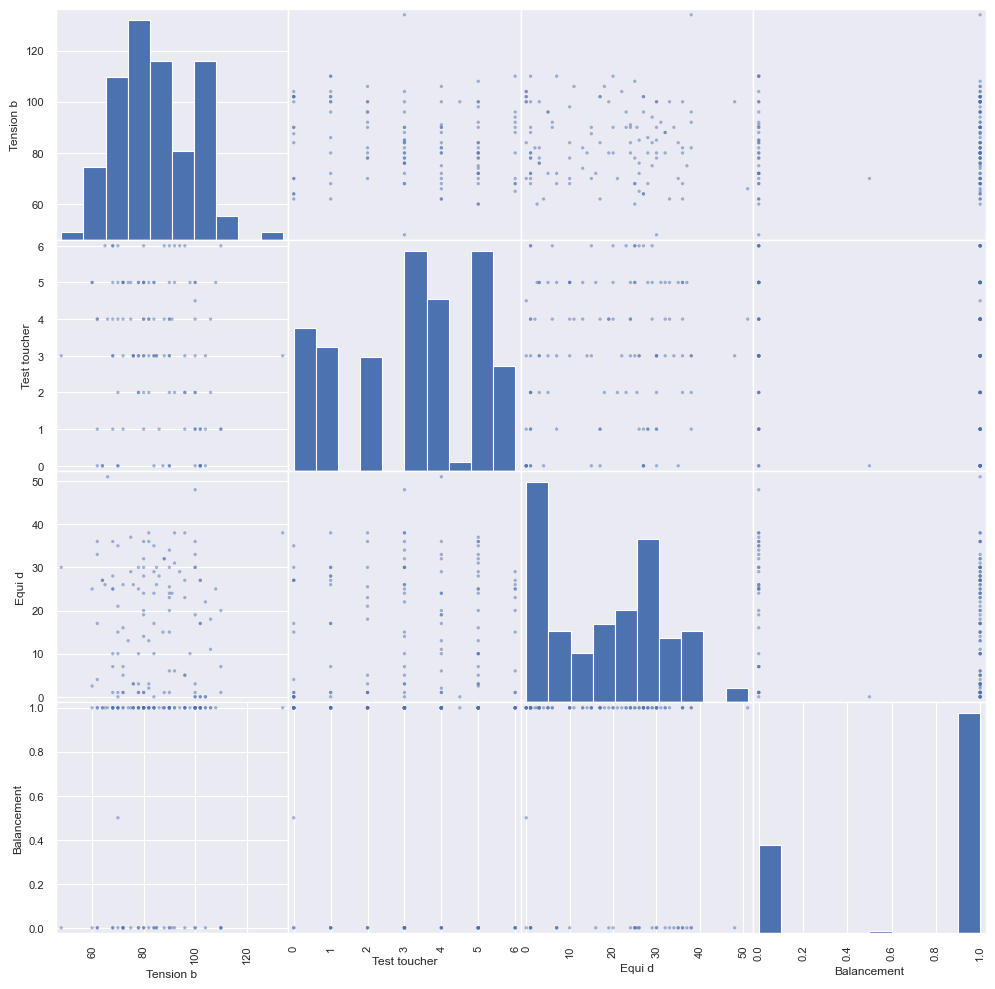

In [63]:
a = [19,20,37,38]
c = []
for i in a:
  c.append(d1.columns[i])
print(c)
pd.plotting.scatter_matrix(d3[c],figsize=(12,12));

In [64]:

d3.to_csv('./outputs/csv/d3.csv')

In [65]:
def encode_pupile_size_noirceur(value):
  mu = 6.41
  ratio = 1.55
  return (value - mu) / ratio
def encode_pupile_size_direct(value):
  mu = 3.35
  ratio = 0.72
  return (value - mu) / ratio
def encode_pupile_size_light(value):
  mu = 3.86
  ratio = 0.93
  return (value - mu) / ratio

In [66]:
d3['Noirceur'] = d3['Noirceur'].apply(encode_pupile_size_noirceur)
d3['Direct'] = d3['Direct'].apply(encode_pupile_size_direct)
d3['Ambiant'] = d3['Ambiant'].apply(encode_pupile_size_light)

In [67]:
type_error = ['Convergence','Perte equilibre', 'Nistagmus vertical', 'Dilatation bond', 'Yeux normaux', 'Pupilles','Injecté sang', 'Conjonctive rouge', 'Larmoyant', 'Nistagmus horizontal','Paupieres', 'Injection','Sautillement','Depot pied','Tonus musculaire']
d3[type_error] = d3[type_error].astype('int64')


In [68]:
line = datasets[0].iloc[1][EXPLICATIVES_COLUMNS]
line[type_error] = line[type_error].astype('int64')
line.to_dict()

{'Reaction lum': 1.0,
 'Depot pied': 1.0,
 'Sautillement': 0.0,
 'Bras': 0.0,
 'Balancement': 0.0,
 'Equi d': 19.0,
 'Equi g': 33.0,
 'Pas 2': 9.0,
 'Pas 1': 9.0,
 'Pivot incorrect': 1.0,
 'Utilisation bras': 0.0,
 'Pas hors ligne': 0.0,
 'Talon/orteille': 1.0,
 'Depart hatif': 0.0,
 'Larmoyant': 0.0,
 'Conjonctive rouge': 0.0,
 'Injecté sang': 1.0,
 'Yeux normaux': 0.0,
 'Ambiant': 6.5,
 'Noirceur': 6.5,
 'Direct': 4.5,
 'Dilatation bond': 1.0,
 'Romberg 1': 0.0,
 'Romberg 2': 0.0,
 'Romberg 3': 10.0,
 'Température': 36.6,
 'Tension a': 170.0,
 'Tension b': 100.0,
 'Test toucher': 4.0,
 'Tonus musculaire': 0.0,
 'Paupieres': 0.0,
 'Pupilles': 0.0,
 'Perte equilibre': 1.0,
 'Pouls': 106.0,
 'Injection': 0.0,
 'Nistagmus horizontal': 0.0,
 'Nistagmus vertical': 0.0,
 'Convergence': 1.0}

In [69]:
ENCODEUR = {'Noirceur':encode_pupile_size_noirceur,'Direct':encode_pupile_size_direct,'Ambiant':encode_pupile_size_light}
encodeurs = dict.fromkeys(EXPLICATIVES_COLUMNS, [])
encodeurs_keys = []
scaler_keys = []
for column in EXPLICATIVES_COLUMNS:
  if not len(d3[column].unique()) in [2,3,4] :
    scaler_keys.append(column)
  else:
    encodeurs_keys.append(column)
    encodeurs[column] = d3[column].value_counts()/d3.shape[0]


In [70]:
scaler = StandardScaler()
d3[scaler_keys] = scaler.fit_transform(d3[scaler_keys])

In [71]:
d3[scaler_keys]

,Equi d,Equi g,Pas 2,Pas 1,Ambiant,Noirceur,Direct,Romberg 1,Romberg 2,Romberg 3,Température,Tension a,Tension b,Test toucher,Pouls
0,-1.413334,-1.390434,0.459857,0.533605,-0.414275,0.464659,0.325856,-1.101303,-1.320205,-0.271882,-0.173722,0.861171,1.079114,-1.670514,0.592267
1,0.035498,1.184593,-0.110661,-0.302857,1.431191,-0.470031,0.325856,-1.101303,-1.320205,-1.200161,0.106163,1.979512,1.079114,0.461862,0.902438
2,0.798041,-1.156340,-0.110661,-0.302857,2.169378,-0.158468,0.325856,-1.101303,-1.015138,-0.596780,0.246106,1.979512,-0.660908,0.461862,1.109218
3,1.408076,1.496718,-0.110661,-0.302857,0.693005,0.464659,0.325856,-1.101303,-1.320205,-0.271882,0.665933,-0.816341,-0.660908,0.994955,1.626170
4,0.111752,-1.312403,-0.110661,-0.302857,-1.152462,-0.470031,-1.416045,-0.143768,0.205131,0.192258,0.525990,0.581586,0.383105,0.994955,-0.545028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,1.331821,0.716406,-0.110661,-0.302857,1.062098,1.399350,-0.022525,-0.303357,-0.557537,-0.364710,-0.033779,-0.928175,-1.148115,-0.071232,-1.268761
112,0.416769,0.482313,-0.110661,-0.302857,0.693005,1.087786,-0.196715,-1.101303,-1.320205,-0.086226,0.246106,0.805254,0.452706,0.461862,-0.028076
113,0.721787,0.560344,-0.110661,0.533605,-0.414275,1.399350,-0.370905,-1.101303,-1.320205,-1.246575,-0.873434,-1.487346,-1.148115,-1.137420,-0.234857
114,0.493024,0.872469,-0.110661,-0.302857,0.693005,1.087786,-0.719285,0.494589,0.205131,-0.643193,-0.313664,2.091346,-1.704922,0.994955,0.902438


In [72]:
encodeurs

{'Reaction lum': Reaction lum
 1.0    0.517241
 0.0    0.448276
 2.0    0.034483
 Name: count, dtype: float64,
 'Depot pied': Depot pied
 1    0.672414
 0    0.327586
 Name: count, dtype: float64,
 'Sautillement': Sautillement
 0    0.732759
 1    0.267241
 Name: count, dtype: float64,
 'Bras': Bras
 1.0    0.698276
 0.0    0.301724
 Name: count, dtype: float64,
 'Balancement': Balancement
 1.0    0.706897
 0.0    0.284483
 0.5    0.008621
 Name: count, dtype: float64,
 'Equi d': [],
 'Equi g': [],
 'Pas 2': [],
 'Pas 1': [],
 'Pivot incorrect': Pivot incorrect
 1.0    0.543103
 0.0    0.405172
 0.5    0.051724
 Name: count, dtype: float64,
 'Utilisation bras': Utilisation bras
 1.0    0.732759
 0.0    0.241379
 0.5    0.025862
 Name: count, dtype: float64,
 'Pas hors ligne': Pas hors ligne
 0.0    0.551724
 1.0    0.413793
 0.5    0.034483
 Name: count, dtype: float64,
 'Talon/orteille': Talon/orteille
 0.0    0.508621
 1.0    0.474138
 0.5    0.017241
 Name: count, dtype: float64,
 '

In [73]:
def integer_column_encoder(column):
  return encodeurs[column]

In [74]:
for column in encodeurs_keys:
  d3[column] = d3[column].apply(lambda x: integer_column_encoder(column)[x])

In [75]:
d3[EXPLICATIVES_COLUMNS]

,Reaction lum,Depot pied,Sautillement,Bras,Balancement,Equi d,Equi g,Pas 2,Pas 1,Pivot incorrect,...,Test toucher,Tonus musculaire,Paupieres,Pupilles,Perte equilibre,Pouls,Injection,Nistagmus horizontal,Nistagmus vertical,Convergence
0,0.517241,0.672414,0.267241,0.698276,0.706897,-1.413334,-1.390434,0.459857,0.533605,0.543103,...,-1.670514,0.560345,0.586207,0.974138,0.698276,0.592267,0.896552,0.525862,0.87069,0.465517
1,0.517241,0.672414,0.732759,0.301724,0.284483,0.035498,1.184593,-0.110661,-0.302857,0.543103,...,0.461862,0.560345,0.586207,0.974138,0.698276,0.902438,0.896552,0.525862,0.87069,0.465517
2,0.448276,0.672414,0.732759,0.698276,0.706897,0.798041,-1.156340,-0.110661,-0.302857,0.543103,...,0.461862,0.560345,0.586207,0.974138,0.301724,1.109218,0.896552,0.474138,0.87069,0.465517
3,0.448276,0.672414,0.732759,0.301724,0.284483,1.408076,1.496718,-0.110661,-0.302857,0.543103,...,0.994955,0.560345,0.586207,0.974138,0.301724,1.626170,0.896552,0.474138,0.87069,0.465517
4,0.448276,0.672414,0.732759,0.301724,0.706897,0.111752,-1.312403,-0.110661,-0.302857,0.405172,...,0.994955,0.560345,0.413793,0.974138,0.698276,-0.545028,0.896552,0.474138,0.12931,0.465517
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,0.517241,0.327586,0.732759,0.698276,0.706897,1.331821,0.716406,-0.110661,-0.302857,0.543103,...,-0.071232,0.560345,0.586207,0.974138,0.301724,-1.268761,0.896552,0.525862,0.87069,0.465517
112,0.448276,0.327586,0.732759,0.301724,0.284483,0.416769,0.482313,-0.110661,-0.302857,0.543103,...,0.461862,0.560345,0.413793,0.974138,0.698276,-0.028076,0.896552,0.525862,0.87069,0.534483
113,0.448276,0.672414,0.267241,0.301724,0.706897,0.721787,0.560344,-0.110661,0.533605,0.543103,...,-1.137420,0.155172,0.586207,0.974138,0.698276,-0.234857,0.896552,0.525862,0.87069,0.534483
114,0.517241,0.327586,0.732759,0.301724,0.284483,0.493024,0.872469,-0.110661,-0.302857,0.405172,...,0.994955,0.284483,0.586207,0.974138,0.301724,0.902438,0.896552,0.525862,0.87069,0.534483


In [76]:
X = d3[EXPLICATIVES_COLUMNS]
y = d3[TARGET]

## Détection des outliers
Test de la meilleur des manieres de supprimer les outliers entre IQR et Z-score avec seuil manuel

### Normalisation des données

### Identification des colonnes qui ont des outliers

### Détection des outliers avec IQR

### Supression d'une colonne des pairs ayant les memes informations

In [77]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_validate
from sklearn.svm import SVC
# Nombre de composantes choisie


d3[TARGET] = d3[TARGET].astype('int64')


print(X.shape)
# Diviser le dataset en ensembles d'entraînement et de test
cv = ShuffleSplit(n_splits=90, test_size=0.1, random_state=0)

# Créer un modèle de régression logistique avec régularisation L2 (Ridge)
alpha = 1  # Paramètre de régularisation, ajustez selon vos besoins
with mlflow.start_run() as run:
  model = SVC(gamma='auto')

  scoring = ['precision_micro', 'roc_auc','recall','accuracy','f1_micro']
  # Entraîner le modèle sur les données d'entraînement
  scores = cross_validate(model, d3[EXPLICATIVES_COLUMNS], d3[TARGET], cv=cv, scoring=scoring,return_train_score=True, return_estimator=True,  return_indices=True)
  print(scores.keys(),"%0.2f accuracy with a standard deviation of %0.2f" % (scores['test_accuracy'].mean(), scores['test_roc_auc'].std()))

  # Sélection du meilleur estimateur (test_recall, test_f1_micro, test_precision_micro, test_accuracy, test_roc_auc)
  index = [np.where(scores['test_recall']==scores['test_recall'].max())[0],np.where(scores['test_f1_micro']==scores['test_f1_micro'].max())[0],np.where(scores['test_precision_micro']==scores['test_precision_micro'].max())[0], np.where(scores['test_accuracy']==scores['test_accuracy'].max())[0],np.where(scores['test_roc_auc']==scores['test_roc_auc'].max())[0]]
  print(index)









(116, 38)


Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py", line 630, in roc_auc_score
    raise ValueError("multi_class must be in ('ovo', 'ovr')")
ValueError: multi_class must be in ('ovo', 'ovr')

  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. Th

dict_keys(['fit_time', 'score_time', 'estimator', 'indices', 'test_precision_micro', 'train_precision_micro', 'test_roc_auc', 'train_roc_auc', 'test_recall', 'train_recall', 'test_accuracy', 'train_accuracy', 'test_f1_micro', 'train_f1_micro']) 0.33 accuracy with a standard deviation of nan
[array([], dtype=int64), array([16, 51, 52, 61]), array([16, 51, 52, 61]), array([16, 51, 52, 61]), array([], dtype=int64)]


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py", line 630, in roc_auc_score
    raise ValueError("multi_class must be in ('ovo', 'ovr')")
ValueError: multi_class

In [78]:
scores

{'fit_time': array([0.00768185, 0.00782585, 0.00875521, 0.00770569, 0.00731683,
        0.0123322 , 0.00965261, 0.00820661, 0.00879788, 0.00802231,
        0.00847411, 0.00780487, 0.00808382, 0.00832129, 0.00974441,
        0.01105833, 0.00720072, 0.01217294, 0.01192355, 0.01098561,
        0.00995445, 0.02055478, 0.01125741, 0.01080418, 0.00997519,
        0.01242924, 0.00991607, 0.01130295, 0.01486826, 0.0164237 ,
        0.00943995, 0.01053405, 0.01253033, 0.01271272, 0.01002645,
        0.01092267, 0.00955534, 0.01196599, 0.01021576, 0.01099634,
        0.00966358, 0.01011276, 0.01249456, 0.01241255, 0.01510096,
        0.01072764, 0.01280427, 0.02182865, 0.01026535, 0.0096662 ,
        0.01266479, 0.01108146, 0.00990462, 0.01203537, 0.01101208,
        0.01457858, 0.01203346, 0.01098776, 0.01098967, 0.01027751,
        0.01046681, 0.01625156, 0.01040745, 0.01147699, 0.01107812,
        0.01471758, 0.01088095, 0.01216078, 0.00842047, 0.00838208,
        0.00841904, 0.0064404 , 0.01

In [79]:
Index = np.concatenate(index)
Index = np.unique(np.array(Index.tolist(), dtype=np.int16)).tolist()
def generate_estimator_short_names(n):
  return [f'E{i+1}' for i in range(n)]

estimators_names = generate_estimator_short_names(len(Index))
Metrics = ['test_recall', 'test_f1_micro', 'test_precision_micro', 'test_accuracy', 'test_roc_auc']
Performances = {'#Indices': []}
maxI = 0
metricMax = 'test_accuracy'
for i in range(len(Metrics)):
  Performances[Metrics[i]] = []
  for j in range(len(Index)):
    Performances[Metrics[i]].append(round(scores[Metrics[i]][Index[j]],2))
    Performances['#Indices'].append(Index[j])
for i in range(len(Index)):
  if Performances[metricMax][i] > Performances[metricMax][maxI]:
    maxI = i
es = pd.DataFrame(Performances,columns=Metrics, index=estimators_names)

es.columns =  es.columns.str.capitalize()
es.columns =  es.columns.str.replace('_', ' ')
es['#Indice'] = Index
es.to_csv('./outputs/csv/estimator_scores.csv')
es


,Test recall,Test f1 micro,Test precision micro,Test accuracy,Test roc auc,#Indice
E1,NaN,0.58,0.58,0.58,NaN,16
E2,NaN,0.58,0.58,0.58,NaN,51
E3,NaN,0.58,0.58,0.58,NaN,52
E4,NaN,0.58,0.58,0.58,NaN,61


In [80]:
Index[maxI]
scores['indices']['test'][16]

array([ 45,  12, 114, 110,  66,  18,  48,  30,  54,  84,  68,  63])

In [81]:
model = scores['estimator'][Index[maxI]]
X_test = X.iloc[scores['indices']['test'][Index[maxI]]]
y_test = y.iloc[scores['indices']['test'][Index[maxI]]]

In [82]:
# Faire des prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les métriques de performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Afficher les métriques de performance
#print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Confusion Matrix:
 [[0 1 0 0 0 0 0]
 [0 1 0 0 0 0 0]
 [0 1 0 0 0 0 0]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 0 2]
 [0 0 0 0 0 2 0]
 [0 0 0 0 0 0 4]]
Classification Report:
               precision    recall  f1-score   support

         8.0       0.00      0.00      0.00         1
        16.0       0.33      1.00      0.50         1
        17.0       0.00      0.00      0.00         1
        18.0       0.00      0.00      0.00         1
        32.0       0.00      0.00      0.00         2
        64.0       1.00      1.00      1.00         2
       128.0       0.57      1.00      0.73         4

    accuracy                           0.58        12
   macro avg       0.27      0.43      0.32        12
weighted avg       0.38      0.58      0.45        12



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


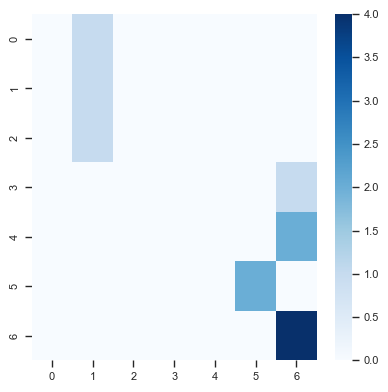

In [83]:
group_names = ['VN','FP','FN','VP','VN','FP','FN','VP','VN','FP','FN','VP','VN','FP']
group_counts = ["{0:0.0f}".format(value) for value in conf_matrix.flatten()]
group_percentages = ['{0:.2%}'.format(value) for value in conf_matrix.flatten()/np.sum(conf_matrix)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(7,2)
with sns.axes_style("ticks"):
  splot = sns.heatmap(conf_matrix,  fmt='', cmap='Blues')
  save_figure(plt,'matrice_confusion_meilleur_estimateur')


In [84]:
# Sauvegarde des models
Path("./outputs/models/").mkdir(parents=True, exist_ok=True)
dump(model, './outputs/models/model.joblib')
dump(f_scaler, './outputs/models/scaler.joblib')
dump(encodeurs, './outputs/models/encodeurs.joblib')
dump(imputer, './outputs/models/imputer.joblib')

dump(pmsb, './outputs/models/pmsb.joblib')
dump(nmsb, './outputs/models/nmsb.joblib')
dump(mask_links, './outputs/models/mask_links.joblib')
dump(regressor, './outputs/models/regressor.joblib')
dump(pencode, './outputs/models/pencode.joblib')
dump(nencode, './outputs/models/nencode.joblib')

with open('./outputs/models/model_input_columns_name.txt', 'w') as f:
  f.write(','.join(EXPLICATIVES_COLUMNS ))
with open('./outputs/models/model_pca_input_columns_name.txt', 'w') as f:
  f.write(','.join(EXPLICATIVES_COLUMNS ))

In [85]:
# Test du chargement des Models et Prediction
input_columns = []
pca_input_columns = []
with open('./outputs/models/model_input_columns_name.txt', 'r') as f:
  f.seek(0)
  input_columns = f.read().split(',')
with open('./outputs/models/model_pca_input_columns_name.txt', 'r') as f:
  f.seek(0)
  pca_input_columns = f.read().split(',')
model = load('./outputs/models/model.joblib')
scaler = load('./outputs/models/scaler.joblib')

X_test = datasets[1][input_columns].iloc[1:10]
X_test[pca_input_columns] = scaler.transform(datasets[1][pca_input_columns].iloc[1:10])
y_pred = model.predict(X_test_r)
y_pred_proba = model.predict_proba(X_test_r)
print(y_pred, y_pred_proba)

IndexError: list index out of range